# Task B: Static (L-I) Characteristcs

## Importing packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from consts import *

## Defining variables

In [ ]:
vg = C/NG # group velocity
alpha_tot = ALPHA_INT + 0.5*np.log(1/(R*R))/L # total alpha loss
vol = L * D * W # volume of the diode
tau_ph = 1/(vg*alpha_tot) # photon lifetime 
g_th = alpha_tot / GAMMA; # gain 
Nth = g_th/B + N0; # carrier density at threshold
Jth = Nth * E * D / (TAU); # current density at threshold
Ith = Jth * L * W # threhold current
lamda = 1.55e-4 # operating wavelength (assumed to be 1.55um)

## Defining current and power axes

In [ ]:
i = np.linspace(0, 60e-3, int(1e4)) # current injection access
eta = ((np.log(1/R)*H*C*vg*tau_ph)/(2*L*E*lamda))
Ps = ((BETA_SP * tau_ph*Nth*H*C*vg*vol*np.log(1/R))/(2*L*lamda*TAU))
p = np.zeros(len(i))
for k in range(0, len(i)):
    if eta*(i[k] - Ith) + Ps < Ps:
        p[k] = Ps
    else:
        p[k] = eta*(i[k]-Ith)+Ps # pout = eta(i-ith) + ps

## Plotting results

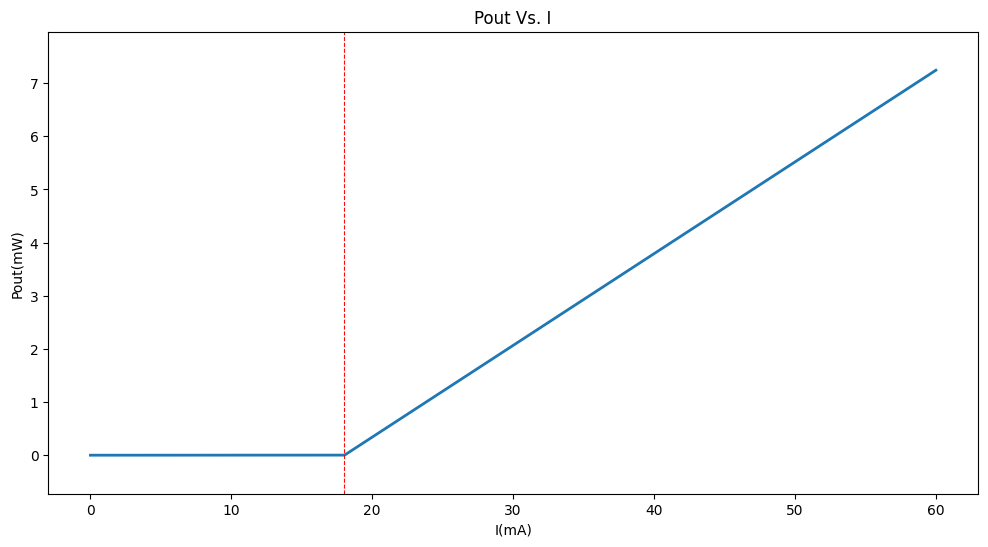

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(i*1e3, p*1e3, lw=2)
plt.title('Pout Vs. I')
plt.ylabel('Pout(mW)')
plt.xlabel('I(mA)')
plt.ylim([-0.1*max(p*1e3), 1.1*max(p*1e3)])
plt.axvline(Ith*1e3, ls='--', lw=0.8, color='r', alpha=0.96)
plt.show()